<a href="https://colab.research.google.com/github/matthewhawksby/colabnotebooks/blob/main/Copy_of_MNE_DataAnalysis_pt2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
!pip install mne
import mne
import os
import sys
import pickle
import numpy as np
import pandas as pd
import glob
import importlib

import helper

#Check if we are in colab.
def in_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

#Load the correct base path depending on if we are in colab or not.
if in_colab():
    from google.colab import drive
    drive.mount('/content/drive')
    base_path = '/content/drive/MyDrive/Colab Notebooks/MNE/mne_data'
else:
    base_path = os.path.join(os.getcwd(), 'mne-data', 'MNE-sample-data')

#Open pickle file and load it into 'blocking'
with open('/content/drive/MyDrive/Colab Notebooks/MNE/bci-main/src/blocking.pkl', 'rb') as f:
    blocking = pickle.load(f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
firstFile = '/content/drive/MyDrive/Colab Notebooks/MNE/MNE_data/m_002/250414/M002_block0_raw.fif'
# Load a raw MEG file
raw = mne.io.read_raw_fif(firstFile, preload=True)

Opening raw data file /content/drive/MyDrive/Colab Notebooks/MNE/MNE_data/m_002/250414/M002_block0_raw.fif...
    Read a total of 13 projection items:
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
    Range : 7000 ... 225999 =      7.000 ...   225.999 secs
Ready.
Reading 0 ... 218999  =      0.000 ...   218.999 secs...


In [18]:

### Find all STI channels
sti_channels = [ch for ch in raw.info['ch_names'] if ch.startswith('STI') or ch.startswith('STI') and ch != 'STI101']
if not sti_channels:
    raise ValueError("No STI channels found in the file")

events = mne.find_events(raw, shortest_event=1)
fs = raw.info['sfreq']

### Print the detected events
events = [(sp/fs, val) for sp, pre, val in events]

all_stimuli = []
count = 0
for time, val in events:
    if val >= 512:
        val -= 512
    if val >= 256:
        val -= 256
    if val == 0 or val == 60:
        continue
    if count == 0:
        all_stimuli.append([])
    all_stimuli[-1].append((time, val))
    count = (count + 1) % 3


322 events found on stim channel STI101
Event IDs: [  32   33   41   42   43   72   73   82   83  256  287  297  327  337
  512  543  553  583  593 1024]


In [19]:
# Load csv, detect presence of button box
dir = "/content/drive/MyDrive/Colab Notebooks/MNE/bci-main/src/data/"
files = glob.glob(dir + "M002_main_2025-04-14_13h48.34.684.csv")
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
print(f"Loaded {len(df)} trials from {len(files)} files.")

if df["key_resp.keys"].notna().sum() > df["buttonBox_2.keys"].notna().sum():
    use_button = False
    print("Using keyboard response")
    response_column = "key_resp.keys"
else:
    use_button = True
    print("Using buttonBox")
    response_column = "buttonBox_2.keys"


Loaded 658 trials from 1 files.
Using buttonBox


In [20]:
# Add correct src path BEFORE importing helper
sys.path.append('/content/drive/MyDrive/Colab Notebooks/MNE/bci-main/src')

import helper
importlib.reload(helper)

tsv_path = "/content/drive/MyDrive/Colab Notebooks/MNE/bci-main/stimuli/demo/*.tsv"
all_data = helper.stimuli_load(tsv_path)

response = {}

for index, row in df.iterrows():
    stimuli = str(row["audio_file"]).replace("\\", "/")
    resp = row[response_column]

    if stimuli.lower() == "nan":
        continue

    if str(resp).lower() == "nan":
        resp = -1
    else:
        resp = int(resp)
        if not use_button:
            resp = resp - 1

    response[stimuli] = {}
    response[stimuli]["response"] = resp

for stimuli in response:
    for key in ["speaker", "sibilants", "normality", "perplexity", "tgt_word", "tgt_sound"]:
        if stimuli not in all_data:
          print("Missing:", stimuli)
          print("Closest matches:", [k for k in all_data if row['audio_file'] in k])
          continue  # Skip this row
        response[stimuli][key] = all_data[stimuli][key]


    if "bot" in response[stimuli]["speaker"]:
        response[stimuli]["speaker"] = "bot"
    else:
        response[stimuli]["speaker"] = "human"

    if response[stimuli]["sibilants"] == "nonsibilant":
        sound_pair = ["f", "θ"]
    else:
        sound_pair = ["s", "ʃ"]

    resp = response[stimuli]["response"]
    if resp == -1:
        response[stimuli]["resp_correct"] = None
    elif response[stimuli]["tgt_sound"] == sound_pair[resp]:
        response[stimuli]["resp_correct"] = True
    else:
        response[stimuli]["resp_correct"] = False

In [21]:
from collections import Counter

# Collect unmatched stimuli
unmatched = []

for stim in response:
    if stim not in all_data:
        unmatched.append(stim)

# Show summary and a preview
print(f"\n🚨 Unmatched stimuli: {len(unmatched)}")
if unmatched:
    print("Here are a few examples:")
    for stim in unmatched[:10]:
        print(" -", stim)


# -------------------------------------
# Filter: Only valid, annotated trials
# -------------------------------------
cleaned_response = {}

for stim, data in response.items():
    if stim not in all_data:
        continue  # skip if not in master stimuli list
    if "normality" not in data or "resp_correct" not in data:
        continue  # skip incomplete data
    cleaned_response[stim] = data

r = cleaned_response

# -------------------------------------
# Quick sanity check
# -------------------------------------
print(f"📊 Total entries in response: {len(response)}")
print(f"✅ Valid/filtered entries: {len(r)}\n")

# Optional peek at sample
for i, (k, v) in enumerate(r.items()):
    print(f"{k}: {v}")
    if i >= 4:
        break
# -------------------------------------
# Filtering logic
# -------------------------------------
def eval(i, cond):
    if "nor" in cond and i["normality"] != "normal":
        return False
    if "abn" in cond and i["normality"] != "abnormal":
        return False
    if "sib" in cond and i["sibilants"] != "sibilant":
        return False
    if "nos" in cond and i["sibilants"] != "nonsibilant":
        return False
    if "man" in cond and i["speaker"] != "human":
        return False
    if "bot" in cond and i["speaker"] != "bot":
        return False
    if "cor" in cond and i["resp_correct"] is not True:
        return False
    if "err" in cond and i["resp_correct"] is not False:
        return False
    return True

def count(r, cond=[]):
    return sum(1 for v in r.values() if eval(v, cond))

def rate(r, cond=[]):
    num = count(r, ["cor"] + cond)
    denom = count(r, cond)
    if denom == 0:
        print(f"[⚠️] No trials matched condition: {cond}")
        return 0.0
    return num / denom * 100

# -------------------------------------
# Breakdown
# -------------------------------------
print("📊 Normality distribution:")
print(Counter([v["normality"] for v in r.values()]))
print()

print("🧠 Total valid trials:", len(r))
print(f"✅ Overall recall: {rate(r, []):.2f}%")

def show_rate(label, cond):
    print(f"{label:<30} {rate(r, cond):>6.2f}%")

print("\n▶️ Condition breakdown:")
show_rate("Normal trials", ["nor"])
show_rate("Abnormal trials", ["abn"])
show_rate("Normal + Bot", ["nor", "bot"])
show_rate("Abnormal + Bot", ["abn", "bot"])
show_rate("Normal + Human", ["nor", "man"])
show_rate("Abnormal + Human", ["abn", "man"])

show_rate("Normal + Bot + Sibilant", ["nor", "bot", "sib"])
show_rate("Abnormal + Bot + Sibilant", ["abn", "bot", "sib"])
show_rate("Normal + Human + Sibilant", ["nor", "man", "sib"])
show_rate("Abnormal + Human + Sibilant", ["abn", "man", "sib"])

show_rate("Normal + Bot + Nonsibilant", ["nor", "bot", "nos"])
show_rate("Abnormal + Bot + Nonsibilant", ["abn", "bot", "nos"])
show_rate("Normal + Human + Nonsibilant", ["nor", "man", "nos"])
show_rate("Abnormal + Human + Nonsibilant", ["abn", "man", "nos"])




🚨 Unmatched stimuli: 0
📊 Total entries in response: 656
✅ Valid/filtered entries: 656

../stimuli/demo/F001/F001_he_saw_the_little_bear_shake.wav: {'response': 1, 'speaker': 'human', 'sibilants': 'sibilant', 'normality': 'normal', 'perplexity': '636.5484564957710', 'tgt_word': 'shake', 'tgt_sound': 'ʃ', 'resp_correct': True}
../stimuli/demo/bot2/bot2_cats_are_known_to_easily_said.wav: {'response': 0, 'speaker': 'bot', 'sibilants': 'sibilant', 'normality': 'abnormal', 'perplexity': '2796.690058614258', 'tgt_word': 'said', 'tgt_sound': 's', 'resp_correct': True}
../stimuli/demo/F002/F002_the_book_is_on_a_lower_self.wav: {'response': 1, 'speaker': 'human', 'sibilants': 'sibilant', 'normality': 'abnormal', 'perplexity': '281.6849467843800', 'tgt_word': 'self', 'tgt_sound': 's', 'resp_correct': False}
../stimuli/demo/bot2/bot2_the_group_relaxed_on_the_shore.wav: {'response': 1, 'speaker': 'bot', 'sibilants': 'sibilant', 'normality': 'normal', 'perplexity': '224.39023593088143', 'tgt_word':

In [22]:
import os
import helper

# Flatten the blocking.pkl file
print(f"Total blocks: {len(blocking)}")
print(f"First block (sample): {blocking[0][:5]}")

stimulus_order = []
for block in blocking:
    for entry in block:
        if isinstance(entry, list):
            stimulus_order.extend([e for e in entry if isinstance(e, str)])
        elif isinstance(entry, str):
            stimulus_order.append(entry)

print("✅ Flattened stimulus count:", len(stimulus_order))
print("👀 Sample from stimulus_order:")
for i, stim in enumerate(stimulus_order[:10]):
    print(f"{i+1:2d}: {stim}")

# Load all_data from TSVs
tsv_path = "/content/drive/MyDrive/Colab Notebooks/MNE/bci-main/stimuli/demo/*.tsv"
all_data = helper.stimuli_load(tsv_path)
print("✅ Entries in all_data:", len(all_data))

# Optional: show a few keys from all_data
print("\n📄 Sample keys in all_data:")
for i, key in enumerate(list(all_data.keys())[:10]):
    print(f"{i+1:2d}: {key}")

# Compare each entry
print("\n📊 Matched stimuli with metadata:")
missing = []

for stim in stimulus_order:
    if stim in all_data:
        meta = all_data[stim]
        print(f"{stim} → {meta['normality']}, {meta['sibilants']}, {meta['speaker']}")
    else:
        missing.append(stim)

print(f"\n❌ Unmatched entries: {len(missing)}")
if missing:
    print("🔍 Sample unmatched:")
    for m in missing[:5]:
        print(" -", m)



Total blocks: 8
First block (sample): ['../stimuli/demo/bot2/bot2_the_yellow_paintball_gun_can_suit.wav', '../stimuli/demo/bot/bot_suddenly_he_felt_a_shock.wav', '../stimuli/demo/F002/F002_the_girl_lost_her_new_blue_shoe.wav', '../stimuli/demo/bot/bot_his_gift_is_a_little_blue_shell.wav', "../stimuli/demo/F002/F002_there's_a_fluffy_brown_sock.wav"]
✅ Flattened stimulus count: 656
👀 Sample from stimulus_order:
 1: ../stimuli/demo/bot2/bot2_the_yellow_paintball_gun_can_suit.wav
 2: ../stimuli/demo/bot/bot_suddenly_he_felt_a_shock.wav
 3: ../stimuli/demo/F002/F002_the_girl_lost_her_new_blue_shoe.wav
 4: ../stimuli/demo/bot/bot_his_gift_is_a_little_blue_shell.wav
 5: ../stimuli/demo/F002/F002_there's_a_fluffy_brown_sock.wav
 6: ../stimuli/demo/F001/F001_his_promises_are_easily_said.wav
 7: ../stimuli/demo/F002/F002_she_passes_the_work_to_shoe.wav
 8: ../stimuli/demo/bot2/bot2_the_tools_are_all_in_the_old_shed.wav
 9: ../stimuli/demo/bot/bot_i_recall_what_it_had_shed.wav
10: ../stimuli/demo

In [23]:
import mne
import helper

# --- Load raw MEG file ---
fif_path = "/content/drive/MyDrive/Colab Notebooks/MNE/MNE_data/m_002/250414/M002_block0_raw.fif"
raw = mne.io.read_raw_fif(fif_path, preload=False)
events = mne.find_events(raw, stim_channel="STI101", shortest_event=1)

print(f"\n📦 Total events: {len(events)}\n")

# --- Show how the first few are decoded ---
print("🔍 Preview decoded events:")
for i, e in enumerate(events[:10]):
    decoded = helper.trigger_decode(e[2])
    print(f"{i+1:2d}: Trigger ID={e[2]:>3} → Decoded: {decoded}")

# --- Count word_on events ---
# BEFORE fix: use "speaker" == "word_on"
# AFTER fix: use "trigger" == "word_on"

# Try both ways just to compare
word_on_by_speaker = [e for e in events if helper.trigger_decode(e[2])["speaker"] == "word_on"]
word_on_by_trigger = [e for e in events if helper.trigger_decode(e[2]).get("trigger") == "word_on"]

print(f"\n🎯 Detected word_on events (by 'speaker' == 'word_on'): {len(word_on_by_speaker)}")
print(f"🎯 Detected word_on events (by 'trigger' == 'word_on'): {len(word_on_by_trigger)}")

# Summary
if len(word_on_by_speaker) > 0 and len(word_on_by_trigger) == 0:
    print("🟡 You're using the OLD version of helper.py (abusing 'speaker')")
elif len(word_on_by_trigger) > 0 and len(word_on_by_speaker) == 0:
    print("🟢 You're using the FIXED version of helper.py (correct use of 'trigger')")
elif len(word_on_by_trigger) == 0 and len(word_on_by_speaker) == 0:
    print("❌ No word_on events detected. Either decoding logic is wrong or triggers are missing.")
else:
    print("⚠️ Both speaker/trigger returned results — something is inconsistent.")


word_on_events = [
    e for e in events if helper.trigger_decode(e[2]).get("trigger") == "word_on"
]


Opening raw data file /content/drive/MyDrive/Colab Notebooks/MNE/MNE_data/m_002/250414/M002_block0_raw.fif...
    Read a total of 13 projection items:
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
    Range : 7000 ... 225999 =      7.000 ...   225.999 secs
Ready.
322 events found on stim channel STI101
Event IDs: [  32   33   41   42   43   72   73   82   83  256  287  297  327  337
  512  543  553  583  5

In [24]:

base_path2 = '/content/drive/MyDrive/Colab Notebooks/MNE/MNE_data/m_002/250414'
raw_list = []
# STEP 1: Load response CSV
csv_path = "/content/drive/MyDrive/Colab Notebooks/MNE/bci-main/src/data/M002_main_2025-04-14_13h48.34.684.csv"
df = pd.read_csv(csv_path)

# Normalize audio file paths to match TSV entries
df["audio_file"] = df["audio_file"].str.replace("\\", "/", regex=False)
df["audio_file"] = df["audio_file"].str.replace("../", "../", regex=False)

# Load TSV metadata
tsv_path = "/content/drive/MyDrive/Colab Notebooks/MNE/bci-main/stimuli/demo/*.tsv"
all_data = helper.stimuli_load(tsv_path)

# Filter to trials with valid `trigger_word_on.started`
df = df[df["trigger_word_on.started"].notna()].reset_index(drop=True)

print("📊 Unique values in 'buttonBox_2.keys':")
print(df["buttonBox_2.keys"].unique())

print("\n🔢 Value counts:")
print(df["buttonBox_2.keys"].value_counts(dropna=False))


# STEP 2: Merge into alignment records
records = []


for _, row in df.iterrows():
    stim = row["audio_file"]
    onset = float(row["trigger_word_on.started"])

    response_raw = str(row.get("buttonBox_2.keys")).strip()

    # Accept only "0" or "1"
    response_raw = row.get("buttonBox_2.keys")

    if pd.isna(response_raw):
      response = -1
    else:
      response = int(response_raw)  # either 0 or 1

    rt = row.get("trials.buttonBox_2.rt", None)

    rec = {
        "stimulus": stim,
        "onset_time": onset,
        "response": response,
        "rt": rt
    }

    # Metadata from TSVs
    meta = all_data.get(stim, {})

    # Preserve detailed speaker label
    rec["speaker"] = meta.get("speaker", None)

    rec["presentation.started"] = row.get("presentation.started", None)
    rec["presentation.stopped"] = row.get("presentation.stopped", None)
    rec["trigger_word_on.started"] = row.get("trigger_word_on.started", None)
    rec["trigger_sent_off.stopped"] = row.get("trigger_sent_off.stopped", None)


    # Add grouped speaker_type
    if rec["speaker"] in {"bot", "bot2"}:
        rec["speaker_type"] = "bot"
    elif rec["speaker"] is not None:
        rec["speaker_type"] = "human"
    else:
        rec["speaker_type"] = None

    # Copy other metadata fields
    for key in ["sibilants", "normality", "tgt_sound"]:
        rec[key] = meta.get(key, None)


    # Correctness
    # Determine correctness
    if response == -1 or "tgt_sound" not in meta or "sibilants" not in meta:
        rec["resp_correct"] = None
    else:
        options = ["f", "θ"] if meta["sibilants"] == "nonsibilant" else ["s", "ʃ"]
        if 0 <= response < len(options):
            rec["resp_correct"] = (meta["tgt_sound"] == options[response])
        else:
            rec["resp_correct"] = None  # Invalid index


    records.append(rec)

alignment_df = pd.DataFrame(records)

# Filter to only trials with valid responses
valid_responses = alignment_df[alignment_df["response"] != -1].copy()

# Sort by onset time or keep original
valid_responses = valid_responses.sort_values("onset_time").reset_index(drop=True)

# Print a handful
for i, row in valid_responses.head(20).iterrows():
    options = ["f", "θ"] if row["sibilants"] == "nonsibilant" else ["s", "ʃ"]
    selected = row["response"]
    correct = row["resp_correct"]
    tgt = row["tgt_sound"]

    print(f"""
🧪 Trial {i+1}
Stimulus:     {row['stimulus']}
Onset Time:   {row['onset_time']:.3f} sec
Speaker:      {row['speaker']} | Sibilants: {row['sibilants']} | Normality: {row['normality']}
Target Sound: {tgt}
Options:      {options}
Response:     {selected} → “{options[selected] if 0 <= selected < len(options) else '???'}”
Correct?:     {correct}
RT:           {row['rt']}
""")

print(f"✅ Trials in aligned DataFrame: {len(alignment_df)}")
display(alignment_df)


📊 Unique values in 'buttonBox_2.keys':
[1. 0.]

🔢 Value counts:
buttonBox_2.keys
1.0    358
0.0    298
Name: count, dtype: int64

🧪 Trial 1
Stimulus:     ../stimuli/demo/bot/bot_on_the_chair_there's_a_shock.wav
Onset Time:   0.856 sec
Speaker:      bot | Sibilants: sibilant | Normality: abnormal
Target Sound: ʃ
Options:      ['s', 'ʃ']
Response:     1 → “ʃ”
Correct?:     True
RT:           0.3305066000320948


🧪 Trial 2
Stimulus:     ../stimuli/demo/bot/bot_on_the_chair_there's_a_sock.wav
Onset Time:   0.973 sec
Speaker:      bot | Sibilants: sibilant | Normality: normal
Target Sound: s
Options:      ['s', 'ʃ']
Response:     0 → “s”
Correct?:     True
RT:           0.5667287999531254


🧪 Trial 3
Stimulus:     ../stimuli/demo/bot/bot_the_gun_made_the_bear_sake.wav
Onset Time:   0.988 sec
Speaker:      bot | Sibilants: sibilant | Normality: abnormal
Target Sound: s
Options:      ['s', 'ʃ']
Response:     0 → “s”
Correct?:     True
RT:           0.7634907999890856


🧪 Trial 4
Stimulus:    

,stimulus,onset_time,response,rt,speaker,presentation.started,presentation.stopped,trigger_word_on.started,trigger_sent_off.stopped,speaker_type,sibilants,normality,tgt_sound,resp_correct
0,../stimuli/demo/F001/F001_he_saw_the_little_be...,1.290172,1,0.430092,F001,28.301228,30.206169,1.290172,1.815490,human,sibilant,normal,ʃ,True
1,../stimuli/demo/bot2/bot2_cats_are_known_to_ea...,1.706297,0,0.488677,bot2,30.663890,33.013856,1.706297,2.281612,bot,sibilant,abnormal,s,True
2,../stimuli/demo/F002/F002_the_book_is_on_a_low...,1.315776,1,0.378663,F002,33.522723,35.508966,1.315776,1.899408,human,sibilant,abnormal,s,False
3,../stimuli/demo/bot2/bot2_the_group_relaxed_on...,1.380831,1,0.614011,bot2,35.901857,37.933383,1.380831,1.964504,bot,sibilant,normal,ʃ,True
4,../stimuli/demo/F001/F001_last_night_he_wore_h...,1.682067,0,0.352167,F001,38.570632,41.246699,1.682067,2.590731,human,sibilant,normal,s,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
651,../stimuli/demo/F002/F002_when_bart_got_on_sta...,1.648489,0,0.566488,F002,1930.753060,1933.102880,1.648489,2.265510,human,nonsibilant,normal,f,True
652,../stimuli/demo/F002/F002_i_won't_give_it_any_...,1.040758,1,0.399263,F002,1933.687728,1935.356818,1.040758,1.607850,human,nonsibilant,abnormal,f,False
653,../stimuli/demo/F001/F001_jamie_likes_a_dress_...,1.879608,1,0.493154,F001,1935.781024,1938.254308,1.879608,2.396818,human,nonsibilant,abnormal,θ,True
654,../stimuli/demo/bot/bot_the_shark_has_a_shiny_...,1.255680,0,0.505484,bot,1938.758125,1940.551574,1.255680,1.722624,bot,nonsibilant,normal,f,True


In [25]:
from collections import Counter

def accuracy_by(*conds):
    subset = alignment_df.copy()
    for cond in conds:
        subset = subset[subset[cond[0]] == cond[1]]
    total = len(subset)
    correct = subset["resp_correct"].sum() if total > 0 else 0
    acc = (correct / total * 100) if total else 0.0
    print(f"{' + '.join(f'{k}={v}' for k,v in conds):<40} → {acc:5.2f}% ({correct}/{total})")

accuracy_by(("normality", "normal"))
accuracy_by(("normality", "abnormal"))
accuracy_by(("sibilants", "sibilant"))
accuracy_by(("sibilants", "nonsibilant"))
accuracy_by(("speaker_type", "bot"))
accuracy_by(("speaker_type", "human"))
accuracy_by(("normality", "abnormal"), ("sibilants", "sibilant"), ("speaker_type", "human"))

normality=normal                         → 96.34% (316/328)
normality=abnormal                       → 89.63% (294/328)
sibilants=sibilant                       → 98.75% (316/320)
sibilants=nonsibilant                    → 87.50% (294/336)
speaker_type=bot                         → 91.46% (300/328)
speaker_type=human                       → 94.51% (310/328)
normality=abnormal + sibilants=sibilant + speaker_type=human → 97.50% (78/80)


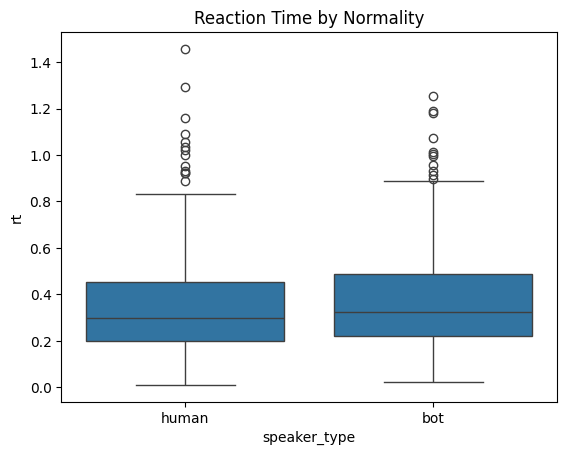

In [26]:
#Reaction Type by Normality

import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=alignment_df, x="speaker_type", y="rt")
plt.title("Reaction Time by Normality")
plt.show()

In [27]:
raw_list = []
for i in range(8):
    fpath = os.path.join(base_path2, f'M002_block{i}_raw.fif')
    raw = mne.io.read_raw_fif(fpath, preload=True, verbose='ERROR')
    raw_list.append(raw)

raw_combined = mne.concatenate_raws(raw_list, on_mismatch='ignore')

In [28]:
# Ensure both columns are present and clean
valid_times = alignment_df.dropna(subset=["trigger_word_on.started", "trigger_sent_off.stopped"]).copy()

# Calculate duration for each trial
valid_times["duration"] =  valid_times["trigger_sent_off.stopped"] -  valid_times["trigger_word_on.started"]

# Now get stats
min_duration = valid_times["duration"].min()
max_duration = valid_times["duration"].max()
avg_duration = valid_times["duration"].mean()

print(f"📊 Trial durations:")
print(f"  🔹 Min:    {min_duration:.3f} sec")
print(f"  🔹 Max:    {max_duration:.3f} sec")
print(f"  🔹 Mean:   {avg_duration:.3f} sec")

📊 Trial durations:
  🔹 Min:    0.258 sec
  🔹 Max:    0.942 sec
  🔹 Mean:   0.533 sec


In [29]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from mne.time_frequency import tfr_array_morlet

# === Setup ===
sfreq = raw_combined.info['sfreq']
meg_picks = mne.pick_types(raw_combined.info, meg=True, stim=False, eog=False, exclude='bads')

fixed_window_sec = 0.5  # 0.5 seconds
fixed_window_samples = int(fixed_window_sec * sfreq)
cutoff_time = 1600  # seconds

# === Extract fixed-length windows ===
X_raw = []
y = []

for _, row in alignment_df.iterrows():
    if row.get("normality") not in ["normal", "abnormal"]:
        continue
    if np.isnan(row.get("presentation.started")) or np.isnan(row.get("trigger_word_on.started")):
        continue

    word_onset_sec = row["presentation.started"] + row["trigger_word_on.started"]
    word_onset_sample = int(word_onset_sec * sfreq)

    if word_onset_sec < 0 or word_onset_sec + fixed_window_sec > cutoff_time:
        continue

    data = raw_combined.get_data(
        picks=meg_picks,
        start=word_onset_sample,
        stop=word_onset_sample + fixed_window_samples
    )

    X_raw.append(data[np.newaxis, ...])
    y.append(1 if row["normality"] == "abnormal" else 0)

X_raw = np.concatenate(X_raw, axis=0)  # (n_trials, n_channels, n_times)
y = np.array(y)

print(f"✅ Extracted {X_raw.shape[0]} fixed-length trials")
print(f"📐 Trial shape: {X_raw.shape}")

# === Time-Frequency Power ===
frequencies = np.arange(12, 31, 4)  # Higher freqs only: 12,16,20,24,28 Hz
n_cycles = frequencies / 4.0

X_power = tfr_array_morlet(
    X_raw, sfreq=sfreq, freqs=frequencies, n_cycles=n_cycles,
    output='power', decim=2, n_jobs=1
)  # (n_trials, n_channels, n_freqs, n_times)

print(f"✅ TFR shape: {X_power.shape} (should be trials × channels × freqs × times)")

# === Feature Flattening ===
n_trials, n_channels, n_freqs, n_times = X_power.shape
X_feat = X_power.reshape(n_trials, n_channels * n_freqs * n_times)

print(f"✅ Flattened feature shape: {X_feat.shape}")

# === Classifier Runner ===
def run_classifier(name, clf):
    pipe = make_pipeline(
        StandardScaler(),
        PCA(n_components=min(100, X_feat.shape[1])),  # Up to 100 components
        clf
    )

    scores = cross_val_score(pipe, X_feat, y, cv=5, scoring='accuracy')
    print(f"\n🧠 {name} Accuracy (5-fold CV): {scores.mean():.3f} ± {scores.std():.3f}")

    X_train, X_test, y_train, y_test = train_test_split(X_feat, y, stratify=y, test_size=0.2, random_state=42)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Abnormal"])

    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(cmap="Blues", ax=ax, values_format='d')
    plt.title(f"{name} Confusion Matrix (Test Set)")
    plt.grid(False)
    plt.show()

    print(classification_report(y_test, y_pred, target_names=["Normal", "Abnormal"]))

# === Run Classifiers ===
#run_classifier("Logistic Regression (Full TFR Flattened)", LogisticRegression(max_iter=1000))
#run_classifier("Random Forest (Full TFR Flattened)", RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42))
#run_classifier("Gradient Boosting (Full TFR Flattened)", GradientBoostingClassifier(n_estimators=100, random_state=42))
#run_classifier("SVM (Linear) (Full TFR Flattened)", SVC(kernel='linear', random_state=42))



✅ Extracted 532 fixed-length trials
📐 Trial shape: (532, 306, 500)
✅ TFR shape: (532, 306, 5, 250) (should be trials × channels × freqs × times)
✅ Flattened feature shape: (532, 382500)


✅ Shape of X_raw: (532, 306, 500) (trials, channels, timepoints)
✅ Labels distribution: Counter({np.int64(0): 281, np.int64(1): 251})
Channel 1/306 (EOG001): 0.528 vs random 0.528
Channel 2/306 (EOG002): 0.528 vs random 0.528
Channel 3/306 (ECG003): 0.528 vs random 0.528
Channel 4/306 (MEG0111): 0.528 vs random 0.528
Channel 5/306 (MEG0112): 0.528 vs random 0.528
Channel 6/306 (MEG0113): 0.528 vs random 0.528
Channel 7/306 (MEG0121): 0.528 vs random 0.528
Channel 8/306 (MEG0122): 0.528 vs random 0.528
Channel 9/306 (MEG0123): 0.528 vs random 0.528
Channel 10/306 (MEG0131): 0.528 vs random 0.528
Channel 11/306 (MEG0132): 0.528 vs random 0.528
Channel 12/306 (MEG0133): 0.528 vs random 0.528
Channel 13/306 (MEG0141): 0.528 vs random 0.528
Channel 14/306 (MEG0142): 0.528 vs random 0.528
Channel 15/306 (MEG0143): 0.528 vs random 0.528
Channel 16/306 (MEG0211): 0.528 vs random 0.528
Channel 17/306 (MEG0212): 0.528 vs random 0.528
Channel 18/306 (MEG0213): 0.528 vs random 0.528
Channel 19/306

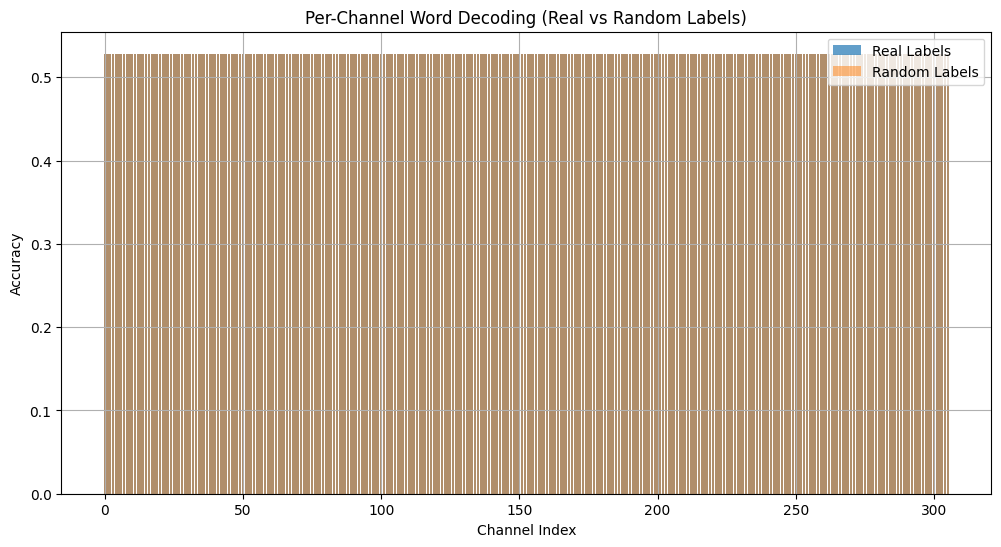


🔝 Top 10 channels by real label decoding:
  1. EOG001 - 0.528 (Random baseline 0.528)
  2. MEG2633 - 0.528 (Random baseline 0.528)
  3. MEG0212 - 0.528 (Random baseline 0.528)
  4. MEG0213 - 0.528 (Random baseline 0.528)
  5. MEG0221 - 0.528 (Random baseline 0.528)
  6. MEG0222 - 0.528 (Random baseline 0.528)
  7. MEG0223 - 0.528 (Random baseline 0.528)
  8. MEG0231 - 0.528 (Random baseline 0.528)
  9. MEG0232 - 0.528 (Random baseline 0.528)
  10. MEG0233 - 0.528 (Random baseline 0.528)


In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from collections import Counter

# === Setup ===
sfreq = raw_combined.info['sfreq']
channel_names = [raw_combined.ch_names[i] for i in range(X_raw.shape[1])]

channel_scores = []
baseline_scores = []

# === Classifier settings ===
clf = LogisticRegression(max_iter=1000, solver='liblinear')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"✅ Shape of X_raw: {X_raw.shape} (trials, channels, timepoints)")
print(f"✅ Labels distribution: {Counter(y)}")

# === Decode each channel individually ===
for ch_idx, ch_name in enumerate(channel_names):
    X_ch = X_raw[:, ch_idx, :]  # (n_trials, n_times)

    # Flatten per trial
    X_ch_flat = X_ch.copy()

    # Sanity check shapes
    if np.isnan(X_ch_flat).any():
        print(f"⚠️ NaNs detected in channel {ch_name}, skipping...")
        channel_scores.append(np.nan)
        baseline_scores.append(np.nan)
        continue

    # Cross-validate
    try:
        score = cross_val_score(clf, X_ch_flat, y, cv=cv, scoring='accuracy').mean()

        # Random labels baseline
        random_labels = np.random.permutation(y)
        baseline = cross_val_score(clf, X_ch_flat, random_labels, cv=cv, scoring='accuracy').mean()

        channel_scores.append(score)
        baseline_scores.append(baseline)

        print(f"Channel {ch_idx+1}/{len(channel_names)} ({ch_name}): {score:.3f} vs random {baseline:.3f}")

    except Exception as e:
        print(f"❌ Error on {ch_name}: {e}")
        channel_scores.append(np.nan)
        baseline_scores.append(np.nan)

channel_scores = np.array(channel_scores)
baseline_scores = np.array(baseline_scores)

# === Plot results ===
plt.figure(figsize=(12, 6))
plt.bar(np.arange(len(channel_scores)), channel_scores, label='Real Labels', alpha=0.7)
plt.bar(np.arange(len(baseline_scores)), baseline_scores, label='Random Labels', alpha=0.5)
plt.xlabel('Channel Index')
plt.ylabel('Accuracy')
plt.title('Per-Channel Word Decoding (Real vs Random Labels)')
plt.legend()
plt.grid(True)
plt.show()

# === Top channels ===
sorted_idx = np.argsort(channel_scores)[::-1]
print("\n🔝 Top 10 channels by real label decoding:")
for i in range(10):
    idx = sorted_idx[i]
    print(f"  {i+1}. {channel_names[idx]} - {channel_scores[idx]:.3f} (Random baseline {baseline_scores[idx]:.3f})")



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# === Try other classifiers ===
#run_classifier("Decision Tree (depth=5)", DecisionTreeClassifier(max_depth=5))
#run_classifier("Random Forest (100 trees)", RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42))
#run_classifier("Gradient Boosting", GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42))
#run_classifier("SVM (RBF Kernel)", SVC(kernel='rbf', gamma='scale'))
#run_classifier("SVM (Linear Kernel)", SVC(kernel='linear'))
#run_classifier("KNN (k=5)", KNeighborsClassifier(n_neighbors=5))
#run_classifier("Gaussian Naive Bayes", GaussianNB())



In [ ]:
# === Full Importance Mapping ===

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# === Train Random Forest on full TFR flatten ===
forest = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

pipe = make_pipeline(
    StandardScaler(),
    PCA(n_components=min(100, X_feat.shape[1])),  # match your previous flattening
    forest
)

pipe.fit(X_feat, y)

# === Extract feature importances ===
try:
    clf = pipe.named_steps['randomforestclassifier']
except KeyError:
    clf = pipe.named_steps[list(pipe.named_steps.keys())[-1]]  # fallback in case pipeline changes

importances = clf.feature_importances_

# === Map importances back to channels ===

n_trials, n_channels, n_freqs, n_times = X_power.shape
features_per_channel = n_freqs * n_times

channel_importance = np.zeros(n_channels)

for ch in range(n_channels):
    start_idx = ch * features_per_channel
    end_idx = start_idx + features_per_channel
    channel_importance[ch] = importances[start_idx:end_idx].sum()

# Normalize importance for better plotting
channel_importance /= channel_importance.max()

# === Plot: Importance drop-off ===

# Sort channels by importance
sorted_idx = np.argsort(channel_importance)[::-1]
sorted_importance = channel_importance[sorted_idx]
sorted_channels = [raw_combined.info['ch_names'][meg_picks[idx]] for idx in sorted_idx]

# Normal plot
plt.figure(figsize=(14, 6))
sns.barplot(x=sorted_channels, y=sorted_importance)
plt.xticks(rotation=90)
plt.title("Channel Importance (sorted)")
plt.ylabel("Relative Importance")
plt.xlabel("Channel Name")
plt.grid(True)
plt.tight_layout()
plt.show()

# Log-scale plot (optional)
plt.figure(figsize=(14, 6))
sns.barplot(x=sorted_channels, y=np.log10(sorted_importance + 1e-6))  # Add epsilon to avoid log(0)
plt.xticks(rotation=90)
plt.title("Log-Scaled Channel Importance (sorted)")
plt.ylabel("Log10(Relative Importance)")
plt.xlabel("Channel Name")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Print Top 20 Channels ===
print("\n🔍 Top channels by importance:")
for i in range(min(20, len(sorted_idx))):
    ch_name = raw_combined.info['ch_names'][meg_picks[sorted_idx[i]]]
    print(f"{i+1:2d}. {ch_name}  ({sorted_importance[i]:.3f})")
